# Protocol Comparison — Sanity Check

Streams one NWB file per protocol directly from **[DANDI:001550](https://dandiarchive.org/dandiset/001550)**
and compares:
- Session / subject metadata
- State, event, and action type inventories
- Trials table columns (which protocols have stimulus data)
- Trial counts and durations
- State transition graphs
- Task arguments inventory

**11 protocols**: PBups · ProAnti3 · ProAnti3Marino · TaskSwitch · TaskSwitch2 · TaskSwitch3 · TaskSwitch4 · TaskSwitch4double · TaskSwitch4new · TaskSwitch4repeat · TaskSwitch6

No local files required — all data is read from DANDI via HTTP range requests.

## 1. Stream all 11 NWB files from DANDI

In [1]:
import warnings
warnings.filterwarnings("ignore")

import h5py
import remfile
import ndx_structured_behavior  # must be imported before NWBHDF5IO
from dandi.dandiapi import DandiAPIClient
from pynwb import NWBHDF5IO

DANDISET_ID = "001550"

# One representative session per protocol (DANDI asset paths)
PROTOCOL_FILES = {
    "PBups":             "sub-P007/sub-P007_ses-PBups-150414a.nwb",
    "ProAnti3":          "sub-P007/sub-P007_ses-ProAnti3-150331a.nwb",
    "ProAnti3Marino":    "sub-H113/sub-H113_ses-ProAnti3Marino-170517a.nwb",
    "TaskSwitch":        "sub-P007/sub-P007_ses-TaskSwitch-150623a.nwb",
    "TaskSwitch2":       "sub-P007/sub-P007_ses-TaskSwitch2-150828a.nwb",
    "TaskSwitch3":       "sub-P007/sub-P007_ses-TaskSwitch3-151030a.nwb",
    "TaskSwitch4":       "sub-H113/sub-H113_ses-TaskSwitch4-181222a.nwb",
    "TaskSwitch4double": "sub-P124/sub-P124_ses-TaskSwitch4double-190404b.nwb",
    "TaskSwitch4new":    "sub-P013/sub-P013_ses-TaskSwitch4new-170530a.nwb",
    "TaskSwitch4repeat": "sub-P100/sub-P100_ses-TaskSwitch4repeat-190416a.nwb",
    "TaskSwitch6":       "sub-P189/sub-P189_ses-TaskSwitch6-210407a.nwb",
}

# handles[proto] = (remfile.File, h5py.File, NWBHDF5IO) — kept open for lazy reads
handles = {}
nwbs = {}

with DandiAPIClient() as client:
    dandiset = client.get_dandiset(DANDISET_ID, "draft")
    for proto, path in PROTOCOL_FILES.items():
        asset = dandiset.get_asset_by_path(path)
        s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)
        remote_file = remfile.File(s3_url)
        h5_file = h5py.File(remote_file, "r")
        io = NWBHDF5IO(file=h5_file, load_namespaces=True)
        nwbs[proto] = io.read()
        handles[proto] = (remote_file, h5_file, io)
        print(f"  {proto}: {path}")

PROTOCOLS = list(PROTOCOL_FILES.keys())
print(f"\nStreaming {len(nwbs)} NWB files from DANDI:{DANDISET_ID}")

  PBups: sub-P007/sub-P007_ses-PBups-150414a.nwb
  ProAnti3: sub-P007/sub-P007_ses-ProAnti3-150331a.nwb
  ProAnti3Marino: sub-H113/sub-H113_ses-ProAnti3Marino-170517a.nwb
  TaskSwitch: sub-P007/sub-P007_ses-TaskSwitch-150623a.nwb
  TaskSwitch2: sub-P007/sub-P007_ses-TaskSwitch2-150828a.nwb
  TaskSwitch3: sub-P007/sub-P007_ses-TaskSwitch3-151030a.nwb
  TaskSwitch4: sub-H113/sub-H113_ses-TaskSwitch4-181222a.nwb
  TaskSwitch4double: sub-P124/sub-P124_ses-TaskSwitch4double-190404b.nwb
  TaskSwitch4new: sub-P013/sub-P013_ses-TaskSwitch4new-170530a.nwb
  TaskSwitch4repeat: sub-P100/sub-P100_ses-TaskSwitch4repeat-190416a.nwb
  TaskSwitch6: sub-P189/sub-P189_ses-TaskSwitch6-210407a.nwb

Streaming 11 NWB files from DANDI:001550


## 2. Session & subject metadata

In [2]:
import pandas as pd

rows = []
for proto, nwb in nwbs.items():
    sub = nwb.subject
    rows.append({
        "protocol":   proto,
        "session_id": nwb.session_id,
        "start_time": nwb.session_start_time.strftime("%Y-%m-%d %H:%M %Z"),
        "subject_id": sub.subject_id if sub else "—",
        "sex":        sub.sex if sub else "—",
        "dob":        sub.date_of_birth.date() if (sub and sub.date_of_birth) else "—",
        "species":    sub.species if sub else "—",
    })

meta_df = pd.DataFrame(rows).set_index("protocol")
meta_df

,session_id,start_time,subject_id,sex,dob,species
protocol,,,,,,
PBups,PBups-150414a,2015-04-14 11:03,P007,M,2015-02-03,Rattus norvegicus
ProAnti3,ProAnti3-150331a,2015-03-31 11:05,P007,M,2015-02-03,Rattus norvegicus
ProAnti3Marino,ProAnti3Marino-170517a,2017-05-17 04:21,H113,M,2017-02-21,Rattus norvegicus
TaskSwitch,TaskSwitch-150623a,2015-06-23 10:22,P007,M,2015-02-03,Rattus norvegicus
TaskSwitch2,TaskSwitch2-150828a,2015-08-28 13:06,P007,M,2015-02-03,Rattus norvegicus
TaskSwitch3,TaskSwitch3-151030a,2015-10-30 12:29 UTC,P007,M,2015-02-03,Rattus norvegicus
TaskSwitch4,TaskSwitch4-181222a,2018-12-22 12:17 UTC,H113,M,2017-02-21,Rattus norvegicus
TaskSwitch4double,TaskSwitch4double-190404b,2019-04-04 15:32,P124,M,2017-06-06,Rattus norvegicus
TaskSwitch4new,TaskSwitch4new-170530a,2017-05-30 11:49,P013,M,2015-04-07,Rattus norvegicus


## 3. Counts summary: trials, states, events, actions, task arguments

In [3]:
rows = []
for proto, nwb in nwbs.items():
    task = nwb.lab_meta_data["task"]
    rec  = nwb.acquisition["task_recording"]
    trials = nwb.trials
    rows.append({
        "protocol":         proto,
        "n_trials":         len(trials) if trials else 0,
        "n_state_types":    len(task.state_types),
        "n_event_types":    len(task.event_types),
        "n_action_types":   len(task.action_types),
        "n_states":         len(rec.states),
        "n_events":         len(rec.events),
        "n_actions":        len(rec.actions),
        "n_task_args":      len(task.task_arguments),
        "has_stimulus":     "left_hi" in (trials.colnames if trials else []),
        "trial_cols":       len(trials.colnames) if trials else 0,
    })

counts_df = pd.DataFrame(rows).set_index("protocol")
pd.set_option("display.max_columns", None)
counts_df

,n_trials,n_state_types,n_event_types,n_action_types,n_states,n_events,n_actions,n_task_args,has_stimulus,trial_cols
protocol,,,,,,,,,,
PBups,420,31,3,14,5706,3966,2567,282,False,14
ProAnti3,547,34,3,19,6307,11925,835,234,False,17
ProAnti3Marino,597,31,3,19,6896,23185,1320,234,False,16
TaskSwitch,373,15,3,1,3479,3164,214,131,True,28
TaskSwitch2,440,19,3,2,5463,4645,637,135,True,29
TaskSwitch3,674,19,3,2,7814,3543,912,146,True,29
TaskSwitch4,231,21,3,2,3546,1801,384,162,True,30
TaskSwitch4double,180,22,3,3,2993,2367,560,166,True,32
TaskSwitch4new,2517,23,3,3,41941,10546,6420,168,True,30


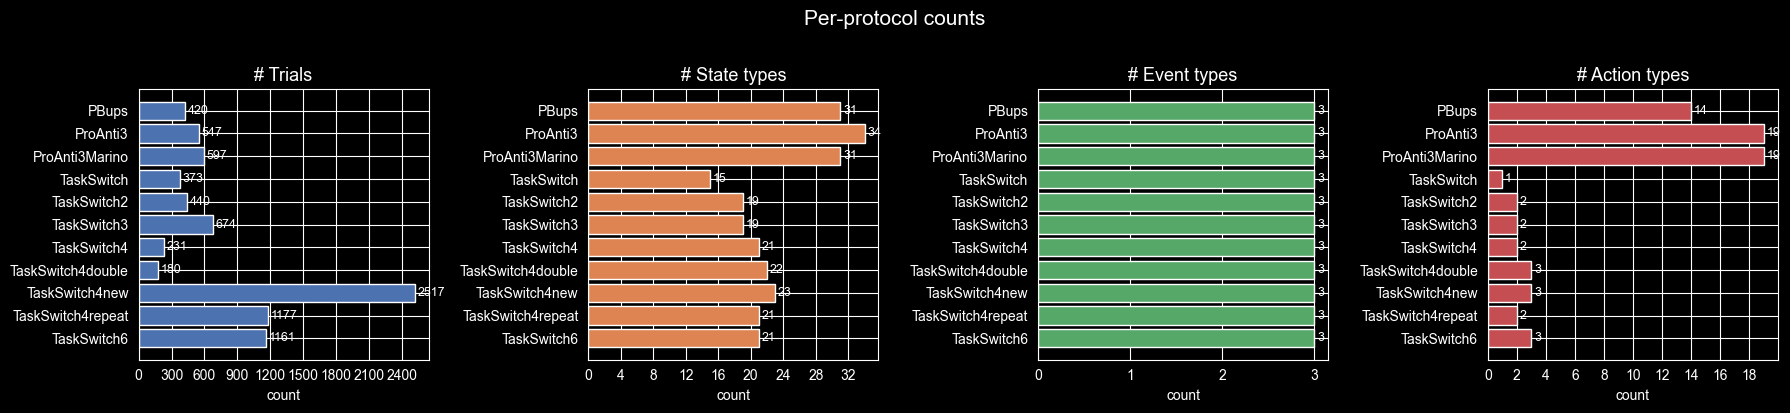

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

cols   = ["n_trials", "n_state_types", "n_event_types", "n_action_types"]
titles = ["# Trials", "# State types", "# Event types", "# Action types"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for ax, col, title, color in zip(axes, cols, titles, colors):
    vals = counts_df[col]
    bars = ax.barh(vals.index, vals.values, color=color, edgecolor="white")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("count")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    for bar, v in zip(bars, vals.values):
        ax.text(v + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                str(v), va="center", fontsize=9)
    ax.invert_yaxis()

plt.suptitle("Per-protocol counts", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 4. State type inventory — which states appear in which protocols?

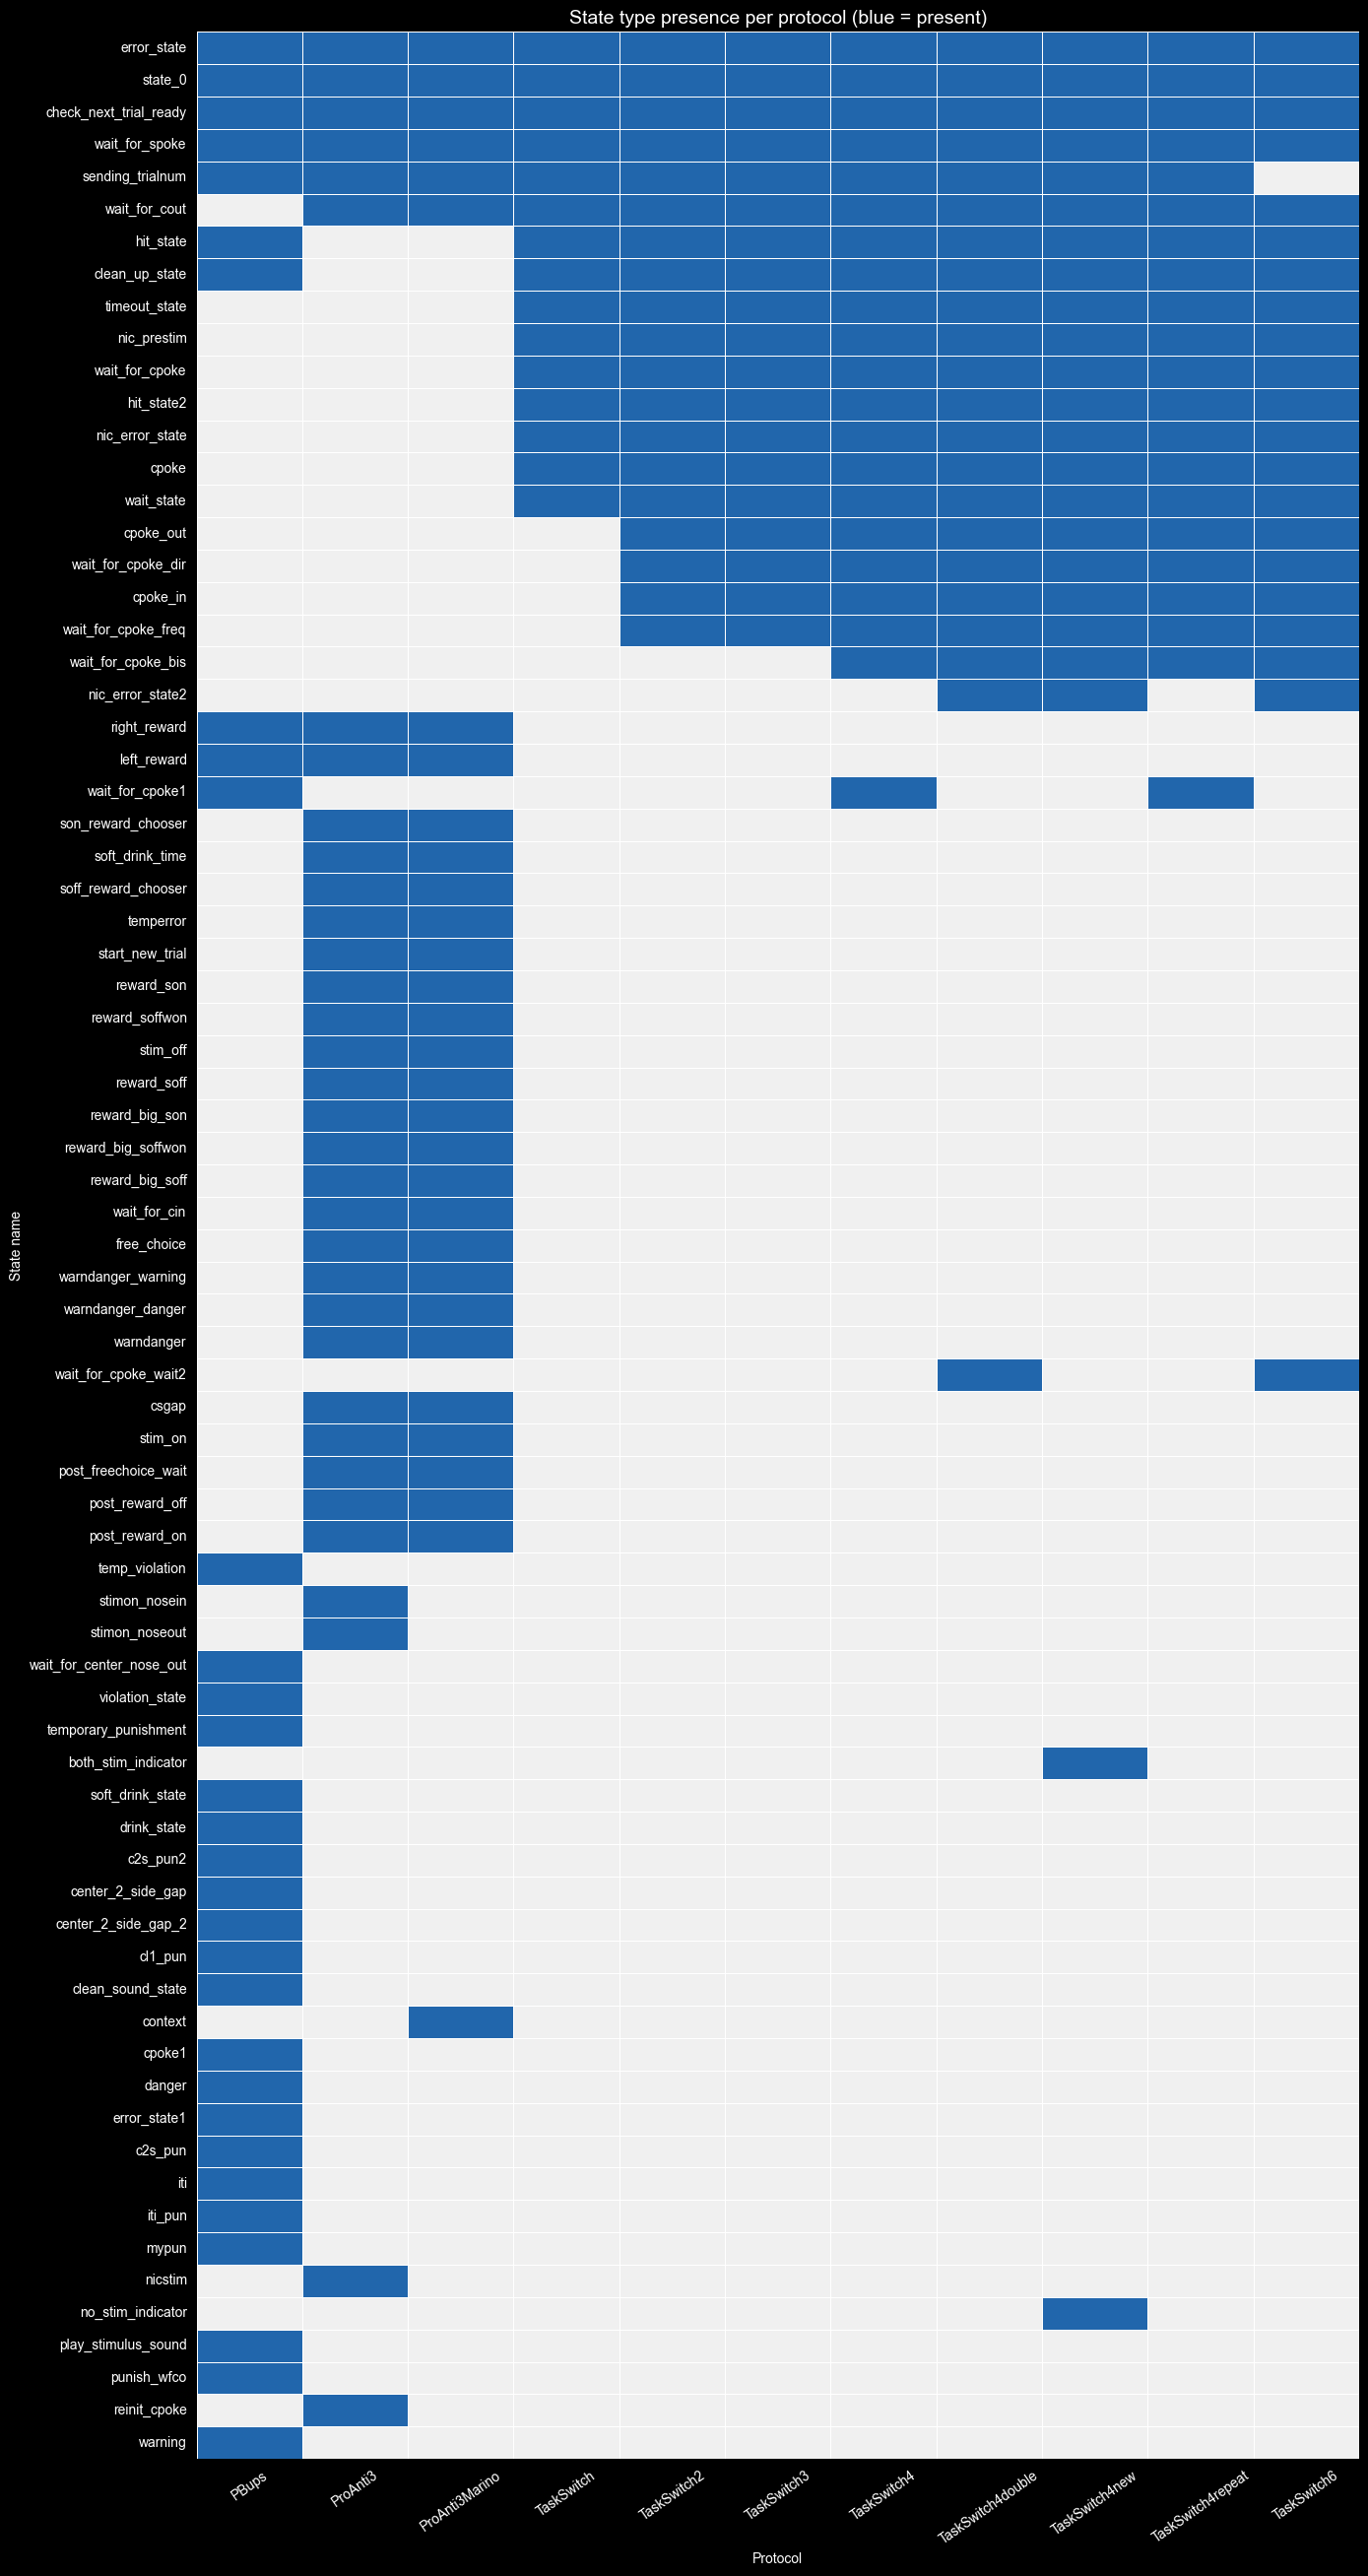

Total unique state types across all protocols: 75


In [5]:
import seaborn as sns

# Build a binary presence matrix: rows = state names, cols = protocols
all_states = sorted({s for p in PROTOCOLS
                     for s in nwbs[p].lab_meta_data["task"].state_types[:]["state_name"]})

state_matrix = pd.DataFrame(
    {proto: [int(s in nwbs[proto].lab_meta_data["task"].state_types[:]["state_name"].values)
             for s in all_states]
     for proto in PROTOCOLS},
    index=all_states
)

# Sort rows by total presence (most common on top)
state_matrix = state_matrix.loc[state_matrix.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, max(6, len(all_states) * 0.35)))
sns.heatmap(
    state_matrix, ax=ax,
    cmap=["#f0f0f0", "#2166ac"],
    vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    cbar=False, annot=False,
    xticklabels=True, yticklabels=True,
)
ax.set_title("State type presence per protocol (blue = present)", fontsize=14)
ax.set_xlabel("Protocol")
ax.set_ylabel("State name")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

print(f"Total unique state types across all protocols: {len(all_states)}")

## 5. Event & action type inventories

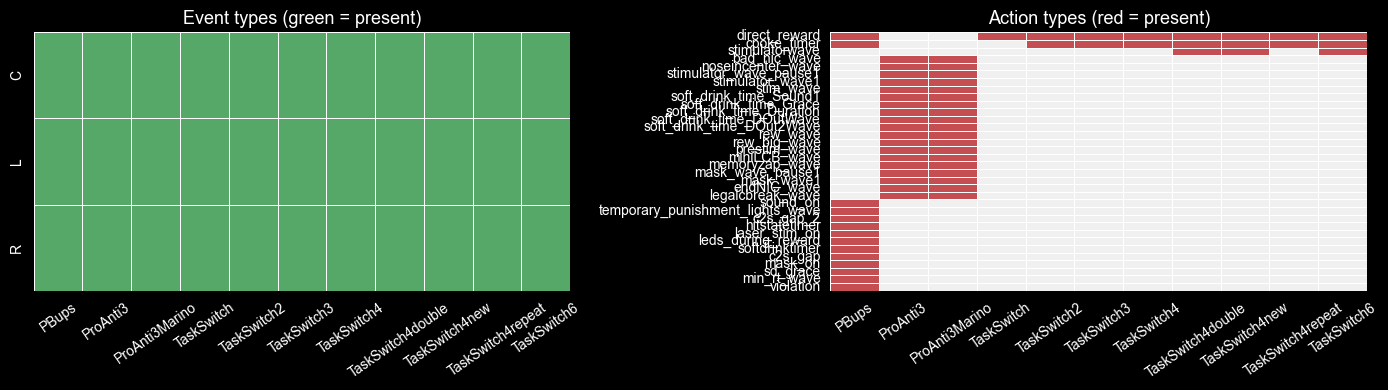

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, kind, col, cmap_color, color_label in [
    (axes[0], "event",  "event_name",  "#55A868", "green"),
    (axes[1], "action", "action_name", "#C44E52", "red"),
]:
    table_attr = f"{kind}_types"
    all_names = sorted({n for p in PROTOCOLS
                        for n in nwbs[p].lab_meta_data["task"].__getattribute__(table_attr)[:][col]})
    matrix = pd.DataFrame(
        {proto: [int(n in nwbs[proto].lab_meta_data["task"].__getattribute__(table_attr)[:][col].values)
                 for n in all_names]
         for proto in PROTOCOLS},
        index=all_names
    )
    matrix = matrix.loc[matrix.sum(axis=1).sort_values(ascending=False).index]
    sns.heatmap(matrix, ax=ax,
                cmap=["#f0f0f0", cmap_color],
                vmin=0, vmax=1,
                linewidths=0.5, linecolor="white",
                cbar=False, xticklabels=True, yticklabels=True)
    ax.set_title(f"{kind.capitalize()} types ({color_label} = present)", fontsize=13)
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

## 6. Trials table columns — which protocols have stimulus data?

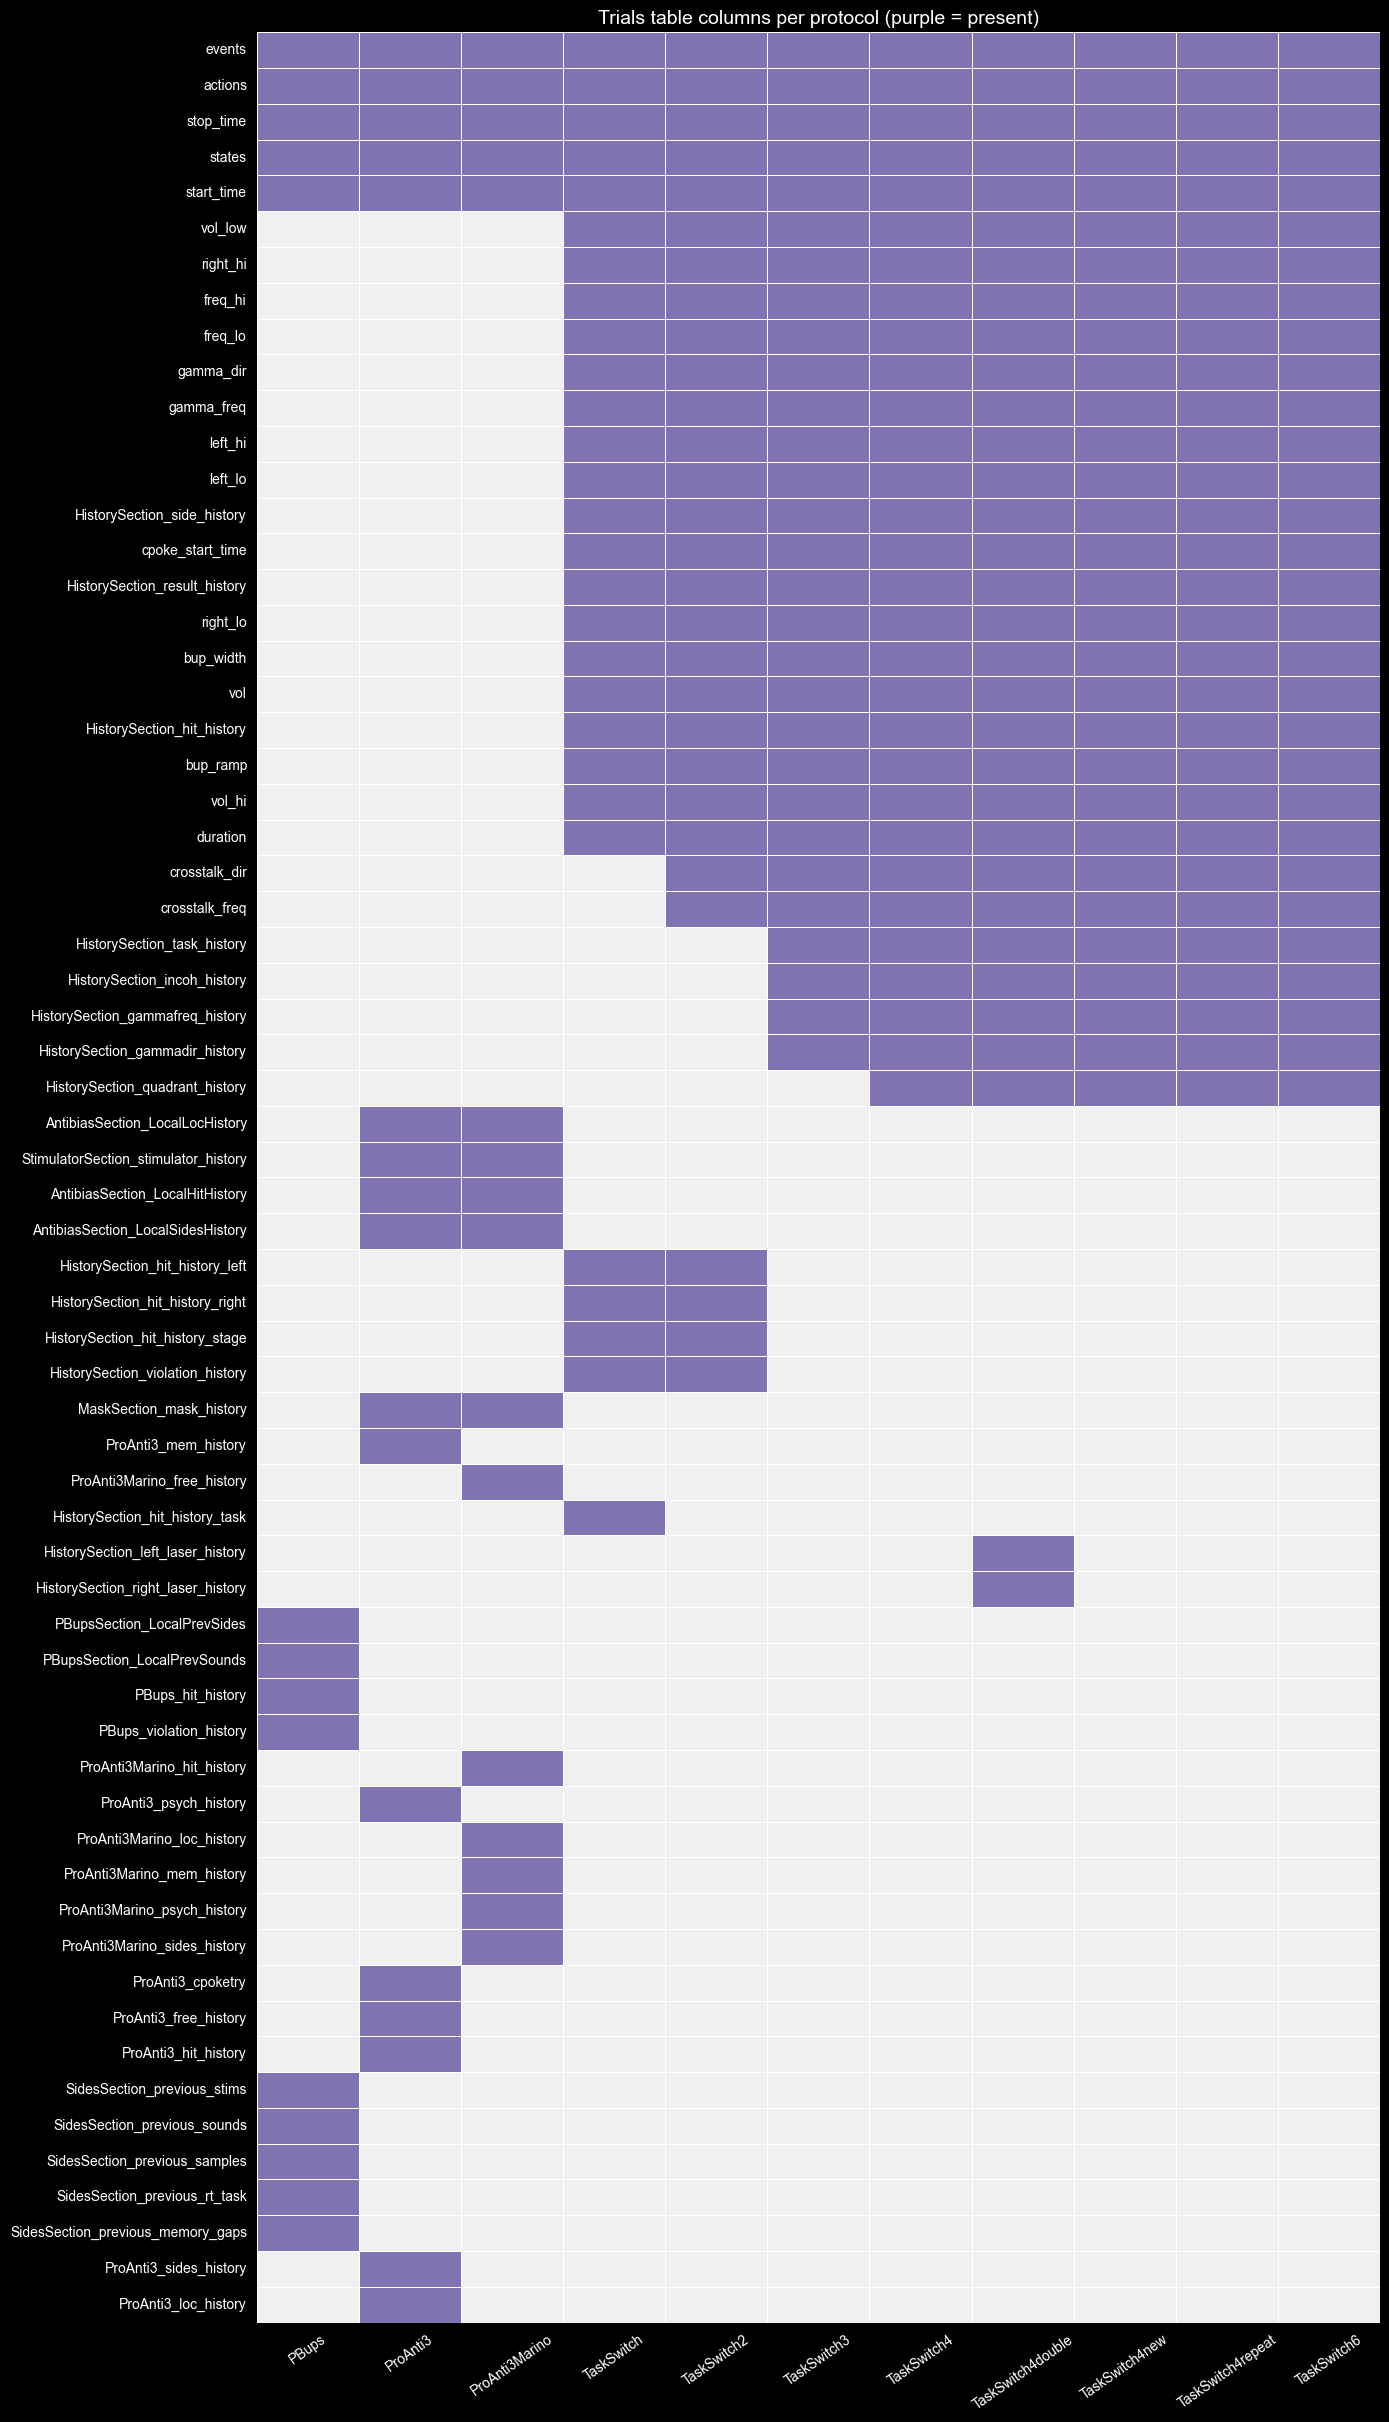

Stimulus-related columns: ['HistorySection_gammadir_history', 'HistorySection_gammafreq_history', 'ProAnti3_cpoketry', 'SidesSection_previous_sounds', 'SidesSection_previous_stims', 'StimulatorSection_stimulator_history', 'cpoke_start_time', 'crosstalk_dir', 'crosstalk_freq', 'freq_hi', 'freq_lo', 'gamma_dir', 'gamma_freq', 'left_hi', 'left_lo', 'right_hi', 'right_lo']


In [7]:
all_cols = sorted({c for p in PROTOCOLS if nwbs[p].trials for c in nwbs[p].trials.colnames})

col_matrix = pd.DataFrame(
    {proto: [int(nwbs[proto].trials is not None and c in nwbs[proto].trials.colnames)
             for c in all_cols]
     for proto in PROTOCOLS},
    index=all_cols
)
col_matrix = col_matrix.loc[col_matrix.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, max(5, len(all_cols) * 0.38)))
sns.heatmap(
    col_matrix, ax=ax,
    cmap=["#f0f0f0", "#8172B2"],
    vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    cbar=False, xticklabels=True, yticklabels=True,
)
ax.set_title("Trials table columns per protocol (purple = present)", fontsize=14)
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

# Highlight stimulus-only columns
stim_cols = [c for c in all_cols if any(kw in c for kw in
    ["left_hi", "right_hi", "left_lo", "right_lo", "cpoke",
     "freq", "gamma", "crosstalk", "sound", "stim"])]
print("Stimulus-related columns:", stim_cols)

## 7. Trial duration distributions

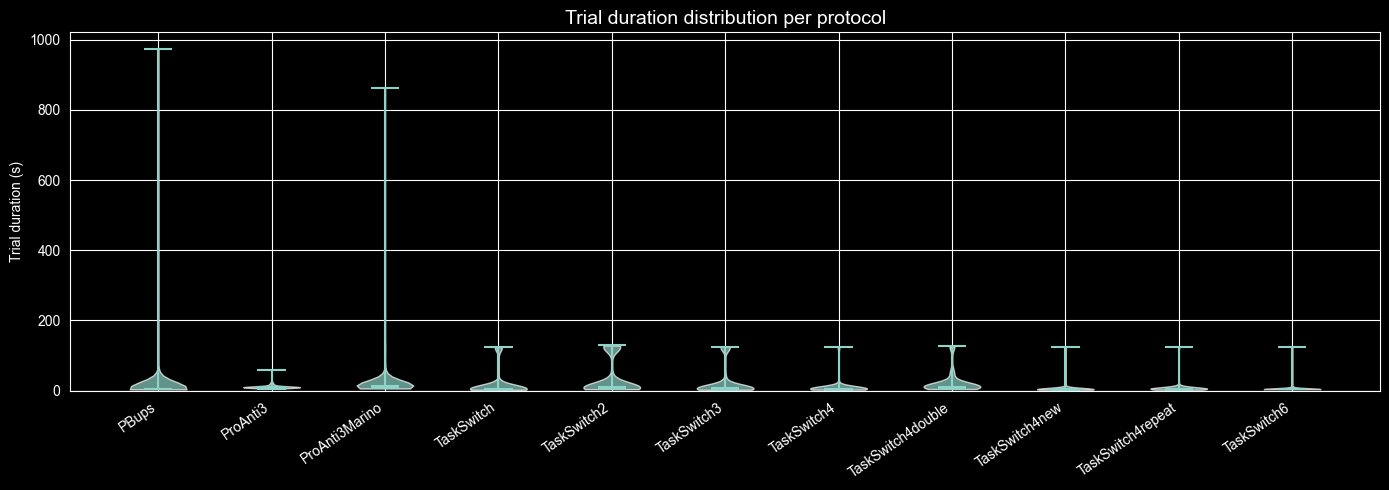

,count,mean,std,min,25%,50%,75%,max
PBups,420.0,15.52,60.50,3.66,4.89,5.66,7.72,972.17
ProAnti3,547.0,11.35,5.91,5.34,8.59,9.95,11.88,57.65
ProAnti3Marino,597.0,20.52,50.52,6.09,9.78,13.06,18.54,860.87
TaskSwitch,373.0,19.14,36.83,2.22,3.95,5.63,7.68,123.86
TaskSwitch2,440.0,35.63,47.54,4.25,6.25,9.94,30.18,128.66
TaskSwitch3,674.0,23.23,39.55,2.42,5.20,6.90,9.71,125.02
TaskSwitch4,231.0,10.15,20.03,2.84,4.56,5.45,7.54,123.53
TaskSwitch4double,180.0,23.07,31.00,4.58,10.17,11.34,18.23,126.02
TaskSwitch4new,2517.0,7.08,16.29,2.72,3.23,3.82,4.91,123.52
TaskSwitch4repeat,1177.0,8.21,15.20,2.65,3.93,5.49,7.59,123.52


In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

durations_per_proto = {}
for proto in PROTOCOLS:
    trials = nwbs[proto].trials
    if trials is None:
        continue
    df = trials.to_dataframe()
    durs = (df["stop_time"] - df["start_time"]).values
    durations_per_proto[proto] = durs

# Violin plot
data   = [durations_per_proto[p] for p in PROTOCOLS if p in durations_per_proto]
labels = [p for p in PROTOCOLS if p in durations_per_proto]

parts = ax.violinplot(data, positions=range(len(data)), showmedians=True, showextrema=True)
for pc in parts["bodies"]:
    pc.set_alpha(0.7)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha="right")
ax.set_ylabel("Trial duration (s)")
ax.set_title("Trial duration distribution per protocol", fontsize=14)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

# Print summary stats
stats = pd.DataFrame({
    proto: pd.Series(durations_per_proto[proto]).describe(percentiles=[.25,.5,.75])
    for proto in labels
}).T.round(2)
stats

## 8. Task arguments inventory across protocols

Total unique task arguments across all protocols: 742


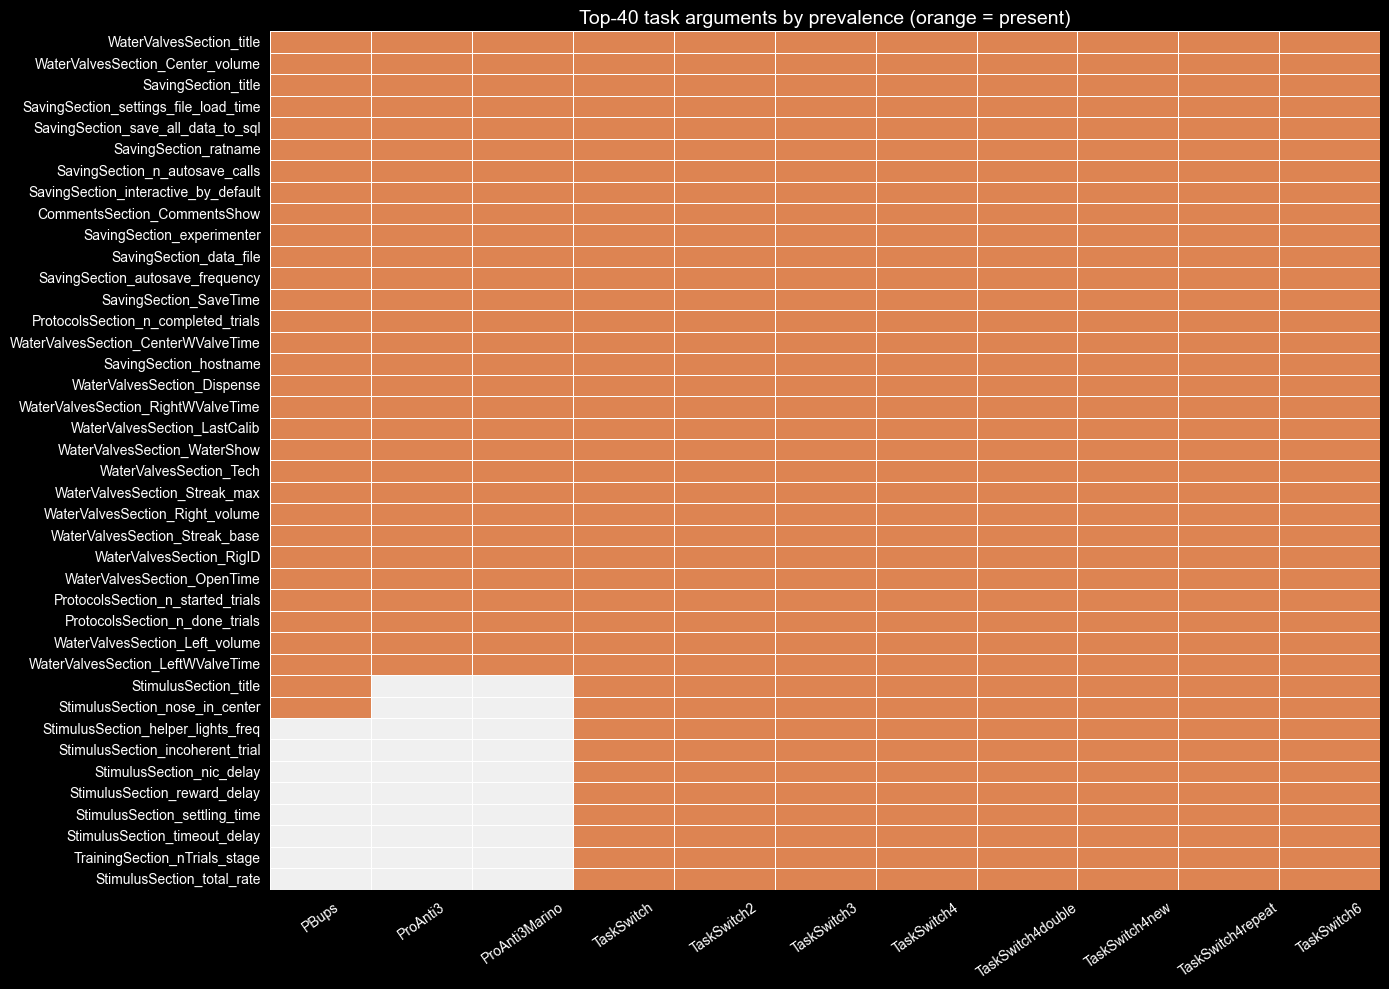

In [9]:
# Which task argument names appear in each protocol?
all_args = sorted({row["argument_name"]
                   for p in PROTOCOLS
                   for _, row in nwbs[p].lab_meta_data["task"].task_arguments[:].iterrows()})

arg_matrix = pd.DataFrame(
    {proto: [int(arg in nwbs[proto].lab_meta_data["task"].task_arguments[:]["argument_name"].values)
             for arg in all_args]
     for proto in PROTOCOLS},
    index=all_args
)
arg_matrix = arg_matrix.loc[arg_matrix.sum(axis=1).sort_values(ascending=False).index]

print(f"Total unique task arguments across all protocols: {len(all_args)}")

# Show top 40 by prevalence to keep the chart readable
top_args = arg_matrix.head(40)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    top_args, ax=ax,
    cmap=["#f0f0f0", "#DD8452"],
    vmin=0, vmax=1,
    linewidths=0.4, linecolor="white",
    cbar=False, xticklabels=True, yticklabels=True,
)
ax.set_title("Top-40 task arguments by prevalence (orange = present)", fontsize=14)
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## 10. Pulse time distribution (TaskSwitch protocols only)

For protocols with stimulus data, plot the distribution of pulse counts per trial for each of the four pulse types.

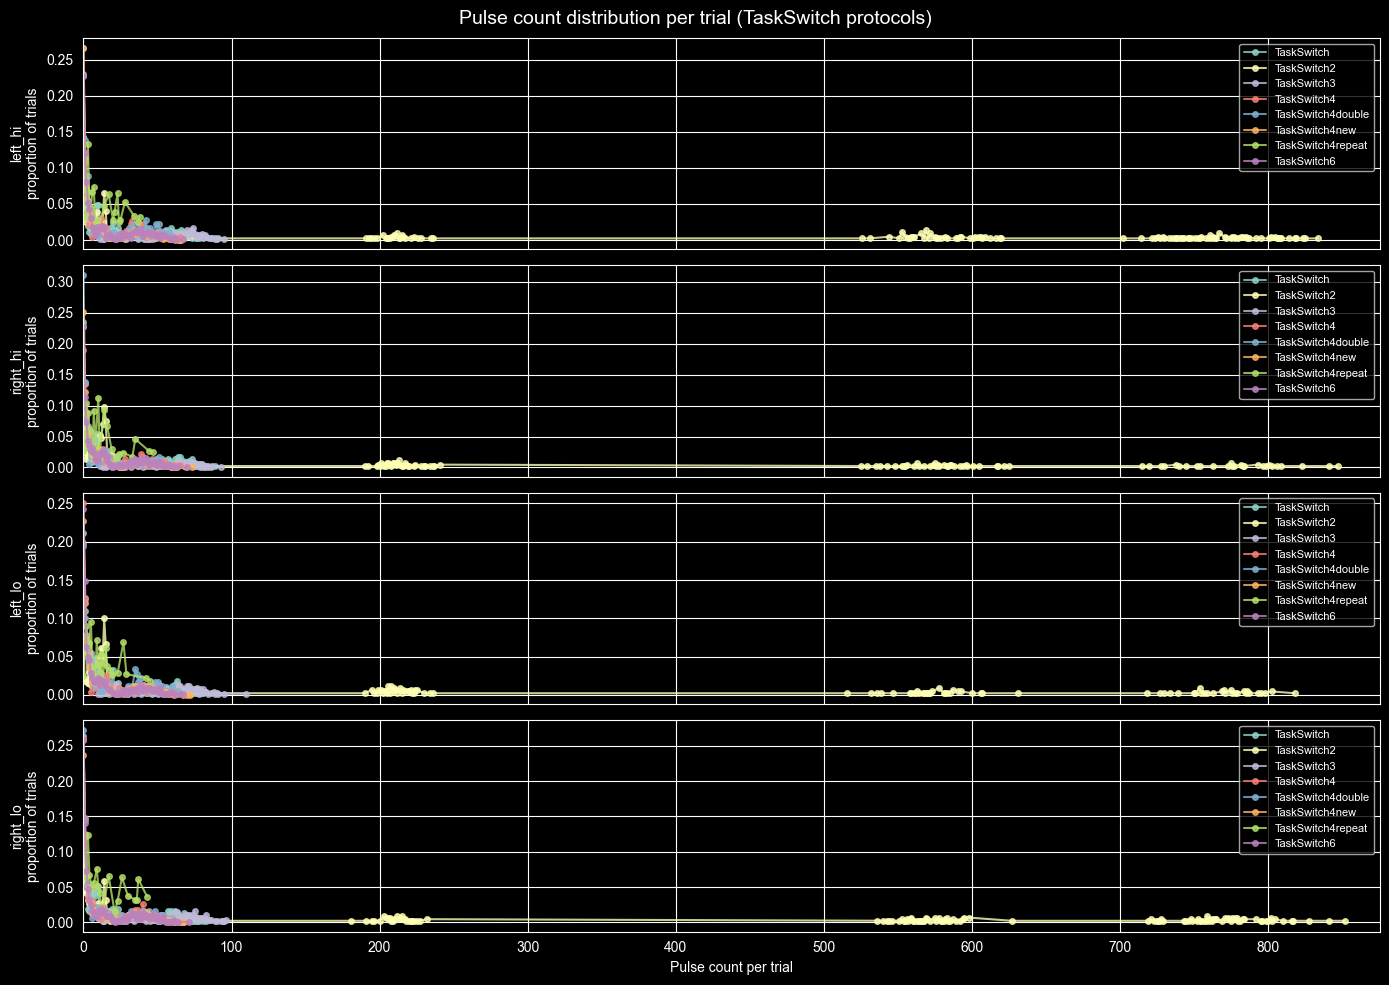

In [11]:
stim_protocols = [p for p in PROTOCOLS
                  if nwbs[p].trials and "left_hi" in nwbs[p].trials.colnames]

pulse_types = ["left_hi", "right_hi", "left_lo", "right_lo"]

fig, axes = plt.subplots(len(pulse_types), 1, figsize=(14, 10), sharex=True)

for ax, pt in zip(axes, pulse_types):
    for proto in stim_protocols:
        trials = nwbs[proto].trials
        counts = [len(trials[pt][i]) for i in range(len(trials))]
        ax.plot(
            sorted(set(counts)),
            [counts.count(c) / len(counts) for c in sorted(set(counts))],
            marker="o", markersize=4, label=proto, alpha=0.8,
        )
    ax.set_ylabel(f"{pt}\nproportion of trials")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlim(left=-0.5)

axes[-1].set_xlabel("Pulse count per trial")
fig.suptitle("Pulse count distribution per trial (TaskSwitch protocols)", fontsize=14)
plt.tight_layout()
plt.show()

## 11. Close all file handles

Close the `NWBHDF5IO`, `h5py.File`, and `remfile.File` layers for each protocol.

In [12]:
for remote_file, h5_file, io in handles.values():
    io.close()
    h5_file.close()
    remote_file.close()
print("All file handles closed.")

All file handles closed.
